In [1]:
%%html
<style>
table {float:left}
</style>

In [2]:
# Thread Limiting (prevent kernel crashes on some Linux machines)
import os

# Limit threads to P-cores only (i9-13900K: 8 Performance cores)
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["TORCH_NUM_THREADS"] = "8"

# Intel-specific thread pinning
os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"

# Session 4:<br>Denoising Quantum Autoencoders

<table>
    <tr><td style="vertical-align: top;"><strong>Aim:</strong></td>
        <td>Create and test a quantum autoencoder (QAE) in PennyLane,<br>
            using time series data with the sliding window protocol.<br>
            Then understand the workings of pure quantum QAE.<br>
            Subsequently, implement a hybrid quantum-classical QAEs.<br>
            Finally, compare both models and their performance.<br>
            To facilitate manipulation of time series windows,<br>
            this notebook uses the provided "window.py" utility functions.
        </td></tr>
    <tr><td style="vertical-align: top;"><strong>Author:</strong></td>
        <td>Jacob L. Cybulski (<a href="https://jacobcybulski.com/" target="_blank">website</a>),
            <em>Enquanted</em></td></tr>
    <tr><td style="vertical-align: top;"><strong>Release:</strong></td>
        <td>September 2025</td></tr>
    <tr><td><strong>Updated:</strong></td>
        <td>October 2026</td></tr>
    <tr><td style="vertical-align: top;"><strong>Datasets</strong></td>
        <td>We will use the the Mackey-Glass time series generator (code included).<br>
            <table style="float: left;">
                <tr><td><em><strong>Mackie-Glass</strong></em></td><td>$\frac{dx(t)}{dt} = \frac{\beta x(t - \tau)}{1 + x(t - \tau)^n} - \gamma x(t)$</td></tr>
            </table>
        </td></tr>
    <tr><td style="vertical-align: top;"><strong>Challenge<br>Tasks:</strong></td>
        <td>Unlimited time</td></tr>
    <tr>
        <td></td>
        <td>Perform the following tasks / challenges<br>(record your observations at the end of this notebook):<br>
        <ol>
            <li>Follow the instructor demo of PennyLane QAE and hybrid PyTorch-PennyLane QAE.</li>
            <li>Explore the Mackie-Glass dataset with a sliding window protocol.</li>
            <li>Understand the implementation of both denoising QAEs.</li>
            <li>Understand the methods of training and scoring of these QAEs.</li>
            <li>Observe how we can plot the performance and fit charts.</li>
            <li>Rewrite the hybrid QAE to separate its encoder and decoder with a classical<br>
                linear layer and add an additional linear layer at the end.</li>
            <li>Test and compare the performance of a pure quantum QAE vs. two hybrid QAEs.</li>
            <li>Improve the new model performance and explain the results.</li>
            <li>Generate 9 instances of differently initialised QAEs, score them and chart the results.</li>
            <li>Plot the data fit (example given) for the best, median and worst performing QAE.</li>
            <li>Reflect on this challenge.</li>
        </ol></td>
    </tr>
    <tr><td style="vertical-align: top;"><strong>References:</strong></td>
        <td><ul>
            <li>Romero, Jonathan, Jonathan P. Olson, and Alan Aspuru-Guzik. 2017.<br>
                <a href="https://iopscience.iop.org/article/10.1088/2058-9565/aa8072/ampdf" target="_blank">“Quantum Autoencoders for Efficient Compression of Quantum Data.”</a><br/>
                Quantum Science and Technology 2 (4): 045001.</li>
            <li>Bravo-Prieto, Carlos,<br>
                <a href="https://iopscience.iop.org/article/10.1088/2632-2153/ac0616/pdf" target="_blank">"Quantum autoencoders with enhanced data encoding."</a><br>
                Machine Learning: Science and Technology, 2, May 2021.</li>
            <li>Phillip Lippe, Tutorial 9: <a href="https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial9/AE_CIFAR10.html" target="_blank">Deep Autoencoders</a>, UvA Deep Learning Tutorials, Fall 2022.</li>
            <li>Ali Shannon, <a href="https://github.com/techshot25/Autoencoders" target="_blank">"techshot25/Autoencoders"</a>, accessed March 12, 2024, GitHub.</li>
        </ul></td>
    </tr>
    <tr><td><strong>License:</strong></td>
        <td>This project is licensed under the 
            <a href="https://www.gnu.org/licenses/gpl-3.0.en.html" target="_blank">GNU General Public License v3</a></td></tr>
    <tr><td><strong>Changes:</strong></td>
        <td>All significant changes to this code must be listed at the bottom of this notebook</td></tr>
</table>

### Quantum Autoencoder (QAE)
In general, autoencoders (AE) are complex neural networks that feature lossy compression of input and recovery of the original data on ooutput.

Quantum autoencoders (QAE) are just quantum implementations of AEs.
In this exeercise, we will explore denoising QAEs, i.e. QAEs able to generate noise-free data on output, when given noisy data on input.
Denoising QAEs processing starts with the QAE encoder, which is responsible for input compression into a latent space that requires fewer qubits than those encoding input data.
The remaining qubits, called trash, will not be needed and will be reinitialised.
What follows is the QAE decoder, responsible fpr decompressing the latent space data into the form, which can be shown to preserve the most important or recurrent features of data on input.
What is lost in this process, via the trash space, is the less significant, noisy, or infrequently occurring data components.

Typical QAE applications include noise reduction from signals (e.g. audio, speech or medical recordings), time-series (e.g. financial or logistic data), and in restoration of images (e.g. old photographs) and videos (e.g. historical movie clips).

The following is an example of a PennyLane implementation of a QAE, with symmetric encoder and decoder, additional qubits (1) for increased expressivity, and a trash space reinitialised using a SWAP operation replacing trash contents with zero initialised qubit states (thus preserving the overall unitary propertoes of QAE).

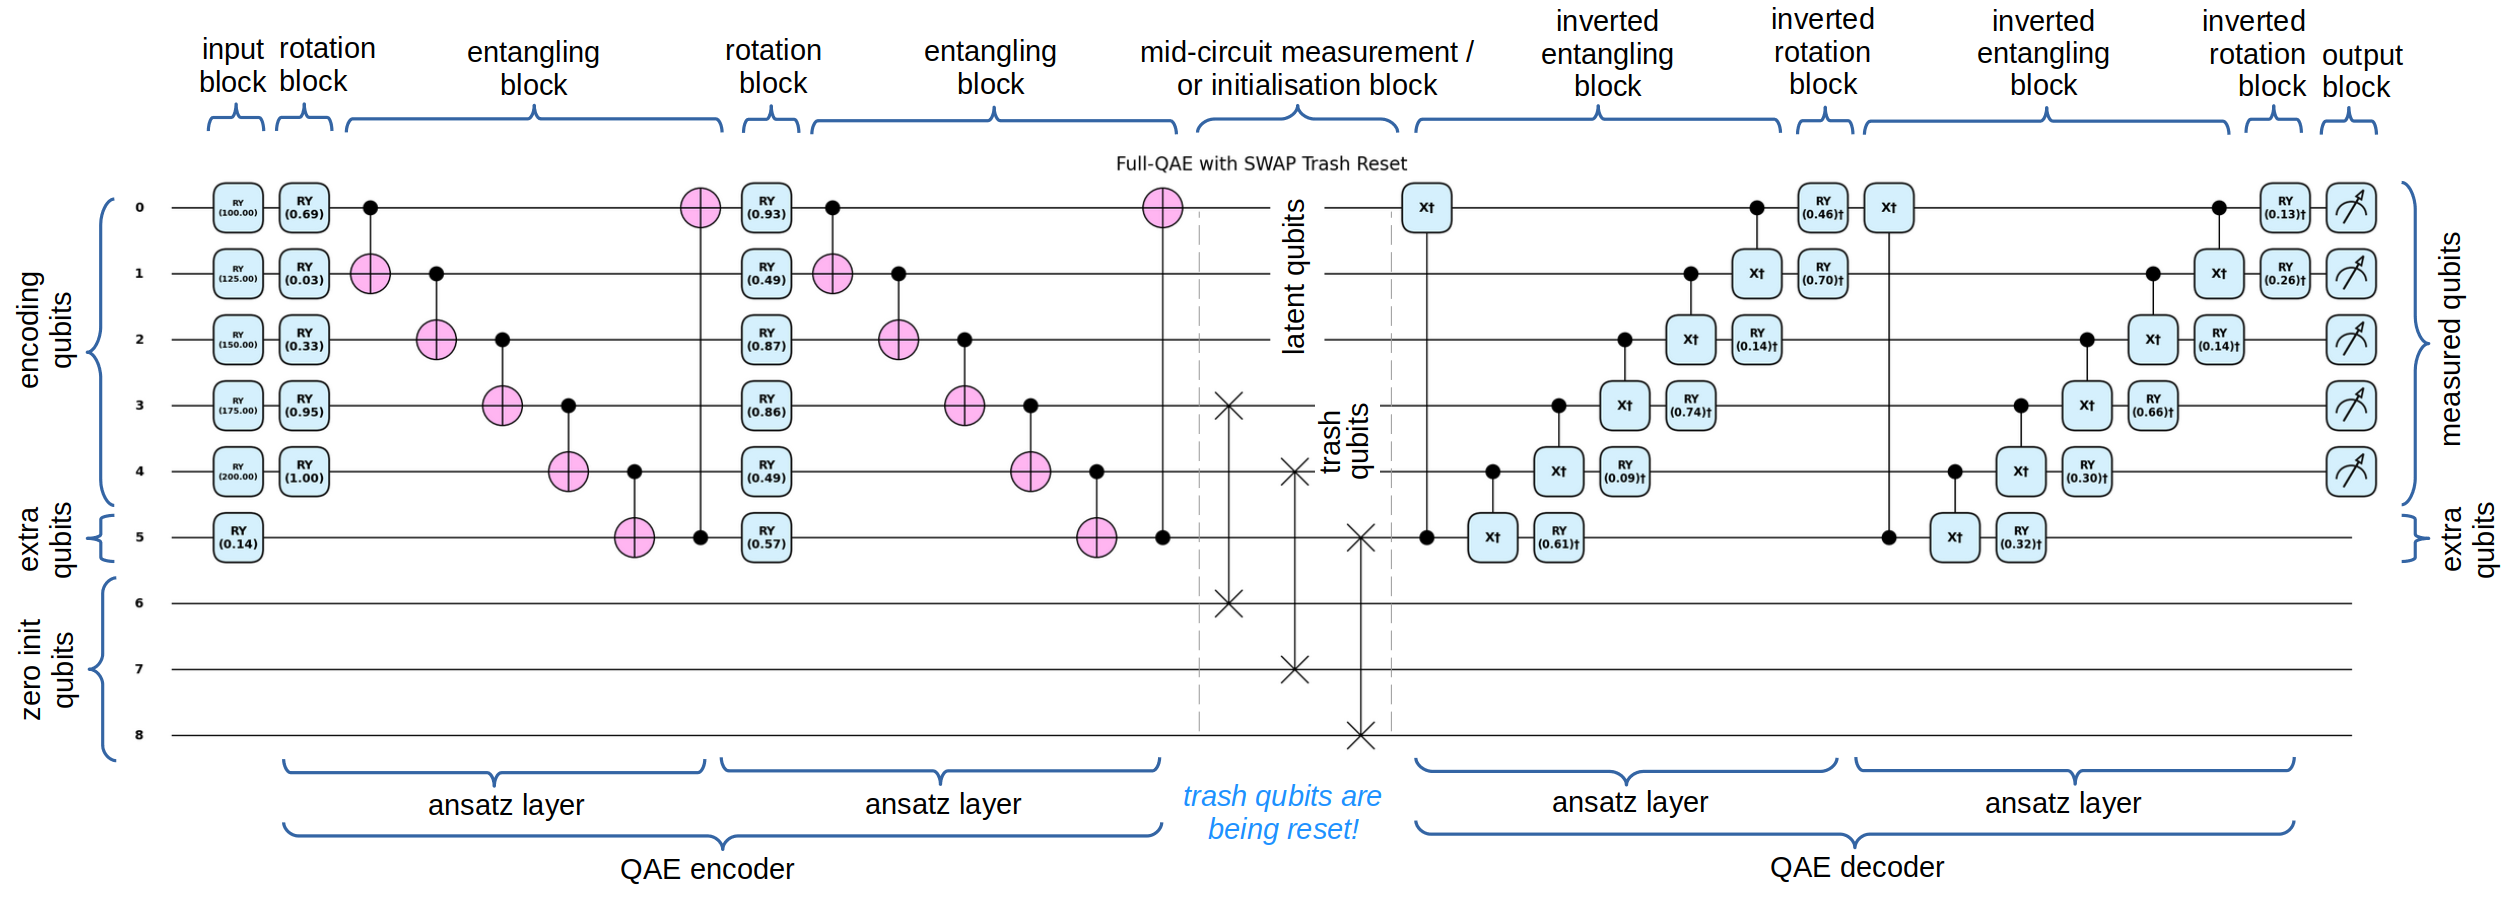

Such a PennyLane model can be "dressed" as a layer of a classical neural network to create a hybrid quantum-classical QAE model. The following is an example of a dressed PennyLane model as a PyTorch layer in the minimalistic hybrid QAE. The model features two small classical linear layers collecting encoder and decoder measurements, but adding a small but effective addition to QAE. In this model, it is possible to mix and match quantum and classical components in any configuration.

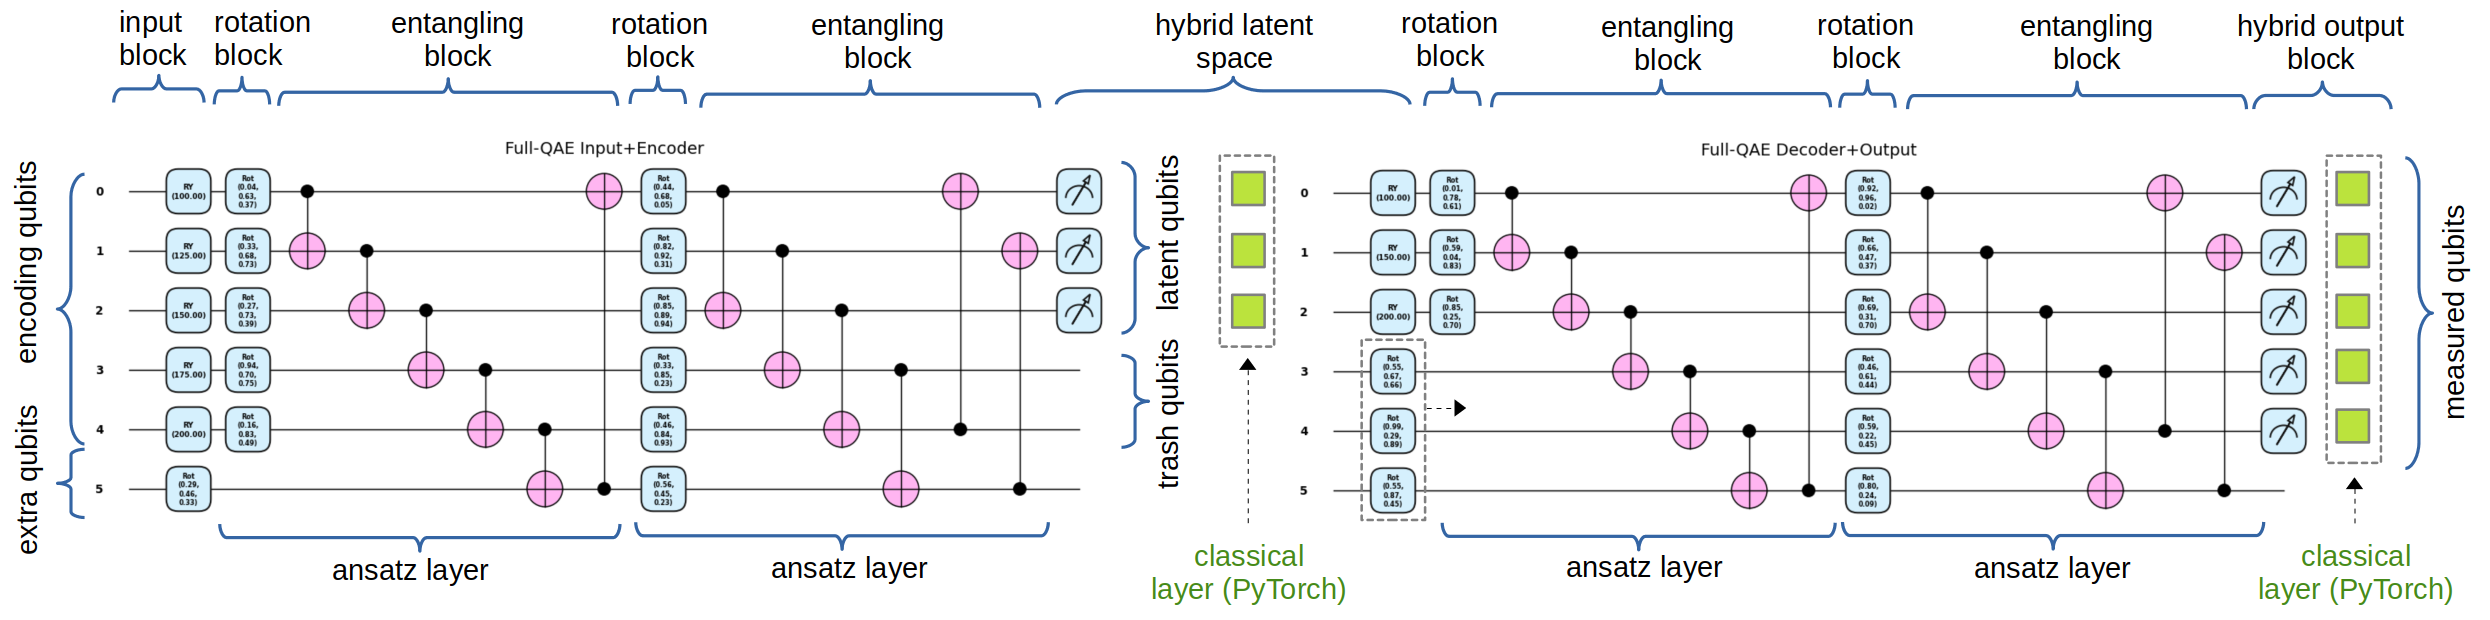

In [3]:
import sys
sys.path.append('.')
sys.path.append('..')
sys.path

['/home/jacob/miniconda3/envs/pl-qml-2026/lib/python311.zip',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/lib-dynload',
 '',
 '/home/jacob/miniconda3/envs/pl-qml-2026/lib/python3.11/site-packages',
 '.',
 '..']

## Libraries

In [4]:
import os
import pylab
import math
import time
import copy
import pandas as pd

from pprint import pprint
import matplotlib
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as np
from torch import nn, optim, sigmoid, softmax
import torch

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from window import ts_add_noise, ts_wind_flatten_avg, ts_wind_make, ts_wind_split, ts_add_noise
from utilities import draw_circuit, meas_plot, multi_plot_series, multi_plot_flat_ts

## Important settings

In [5]:
##### Debugging: 0 - none, 1 - basic, 2 - full
debug_level = 0

In [6]:
##### Default data type for Torch
torch.set_default_dtype(torch.float64)

## Small Utilities

In [7]:
##### Small utilities

### Random seed generator
def rand_seed():
    t=time.time(); t = int((t-int(t))*10000)
    return t

### Data scaler
def scale_values(x, new_min=0, new_max=1):
    scaler = MinMaxScaler(feature_range=(new_min, new_max))
    return scaler.fit_transform(x.reshape(-1, 1)).flatten()

## <font color="blue">Data preparation</font>
<font color="CornflowerBlue">In mathematics and mathematical biology, the Mackey–Glass equations, named after Michael Mackey and Leon Glass, refer to a family of delay differential equations whose behaviour manages to mimic both healthy and pathological behaviour in certain biological contexts, controlled by the equation's parameters (<a href="https://en.wikipedia.org/wiki/Mackey%E2%80%93Glass_equations" target="_blank">Wikipedia</a>).</font>

### The "mackey_glass" time series generator

The generator is based on the differential equation:<br><br>
$\frac{dx(t)}{dt} = \frac{\beta x(t - \tau)}{1 + x(t - \tau)^n} - \gamma x(t)$<br><br>
whith symbols relating to the following Python code variables:
<ul>
    <li>
        <b>$\frac{dx(t)}{dt}$</b>: The rate of change of the variable $x$ with respect to time $t$ (variable <code>dx</code>).
    </li>
    <li>
        <b>$x(t)$</b>: The value of the series at the current time $t$ (variables <code>xt</code> / <code>x[t]</code>).
    </li>
    <li>
        <b>$x(t - \tau)$</b>: The value of the series at a past time, delayed by $\tau$ (variables <code>xt_tau</code> / <code>x[t - tau]</code>).
    </li>
    <li>
        <b>$\beta$</b>: This term controls the production rate (parameter <code>beta</code>. ).
    </li>
    <li>
        <b>$\gamma$</b>: This represents a decay or loss rate (parameter <code>gamma</code>).
    </li>
    <li>
        <b>$n$</b>: This exponent determines the non-linearity of the feedback (parameter <code>n</code>).
    </li>
    <li>
        <b>$\tau$</b>: The time delay (parameter <code>tau</code>).
    </li>
</ul>

In [8]:
##### Mackey-Glass settings

### Mackey-Glass options
beta=0.17    # Larger beta = stronger oscillations
gamma=0.1    # Keeps damping moderate
n=10         # Standard nonlinearity
tau=30       # Introduces chaos (try 17–30 for interesting behavior)
x0=1.2       # Initial condition
length=600   # Length of the generated series 

### Data encoding setting
X_from = 0
X_to =   2*np.pi

y_margin = 0.1
y_low = 0+y_margin
y_high = 1-y_margin

In [9]:
##### Simulates the Mackey-Glass time series

### Mackey-Glass generator
def mackey_glass(length=1300, tau=17, beta=0.2, gamma=0.1, n=10, x0=1.2):
    x = np.zeros(length + tau + 1, dtype=float)
    x[:tau+1] = x0
    for t in range(tau, length + tau):
        xt = x[t]
        xt_tau = x[t - tau]
        dx = beta * xt_tau / (1.0 + xt_tau**n) - gamma * xt
        x[t+1] = xt + dx
    return x[tau+1:]

# Generate the Mackey-Glass time series
y_raw = mackey_glass(length=length, beta=beta, gamma=gamma, n=n, tau=tau, x0=x0)
y_raw = scale_values(y_raw, new_min=y_low, new_max=y_high)
y = y_raw[2::4] # reduce the number of points but keep the shape
X_raw = np.array([i for i in range(len(y))]) # Number points
X = scale_values(X_raw, new_min=X_from, new_max=X_to) # Keep the original coords

n_samples = len(y)

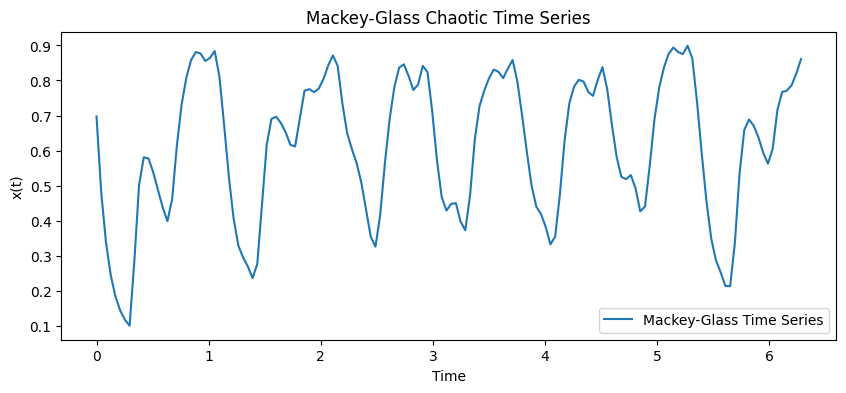

In [10]:
##### Plot the Mackey-Glass time series
plt.figure(figsize=(10, 4))
plt.plot(X, y, label='Mackey-Glass Time Series')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Mackey-Glass Chaotic Time Series')
plt.legend()
plt.show()

### Prepare trainig and testing data partitions
*Note that QAE X and y will be the same (unless noise is injected into X).*<br>
*Also note that initially separate noisy partitions have been generated for visualisation only.*<br>
*In training, different noise is created at each training iteration.*<br>
*This is necessary to prevent QAE to learn the noisy signal itself.*

In [11]:
##### Data settings

### Training / testing data split
split = 2/3

### Window settings
wind_size = 5
wind_step = 2
horizon = 1
noise = 0.2

### Random seed(s)
seed = 2025

In [12]:
##### Create time series tensor data with optional noise 
#     Note that windows overlap by wind_step

def create_sw_tens(X, y, noise=0.0, wind_size=5, wind_step=2, range_low=0.2, range_high=0.8, seed=0):
    y_noisy = ts_add_noise(y, noise=noise, noise_type='normal', clip=False,
        range_low=range_low, range_high=range_high, seed=seed)
    y_ts = ts_wind_make(y_noisy, wind_size, wind_step)
    X_ts = ts_wind_make(X, wind_size, wind_step)
    X_train_ts, y_train_ts, X_test_ts, y_test_ts = ts_wind_split(X_ts, y_ts, split)

    X_train_tens = torch.tensor(X_train_ts, requires_grad=False)
    y_train_tens = torch.tensor(y_train_ts, requires_grad=False)
    X_test_tens = torch.tensor(X_test_ts, requires_grad=False)
    y_test_tens = torch.tensor(y_test_ts, requires_grad=False)
    return X_train_tens, y_train_tens, X_test_tens, y_test_tens

In [13]:
##### Preparation of sliding windows and their partitions

### Create windows and split into training and test partitions
X_train_coords, y_train_coords, X_test_coords, y_test_coords = \
        create_sw_tens(X, X, noise=0.0, wind_size=wind_size, wind_step=wind_step, range_low=y_low, range_high=y_high, seed=seed)
X_train_tens, y_train_tens, X_test_tens, y_test_tens = \
    create_sw_tens(y, y, noise=0.0, wind_size=wind_size, wind_step=wind_step, range_low=y_low, range_high=y_high, seed=seed)
_, X_train_noisy_tens, _, X_test_noisy_tens = \
    create_sw_tens(y, y, noise=noise, wind_size=wind_size, wind_step=wind_step, range_low=y_low, range_high=y_high, seed=seed)

### Find partition sizes
n_train = len(X_train_tens)
n_test = len(X_test_tens)

In [14]:
if debug_level > 0:
    
    ### Print a sample of data
    print('\nSample of training partition:\n\nWindow coordinates:')
    pprint(X_train_coords[0:3])
    print('\nWindow values:')
    pprint(X_train_tens[0:3]); 
    print('\nSample of test partition:\n\nWindow coordinates:')
    pprint(X_test_coords[0:3])
    print('\nWindow values:')
    pprint(X_test_tens[0:3]); print()

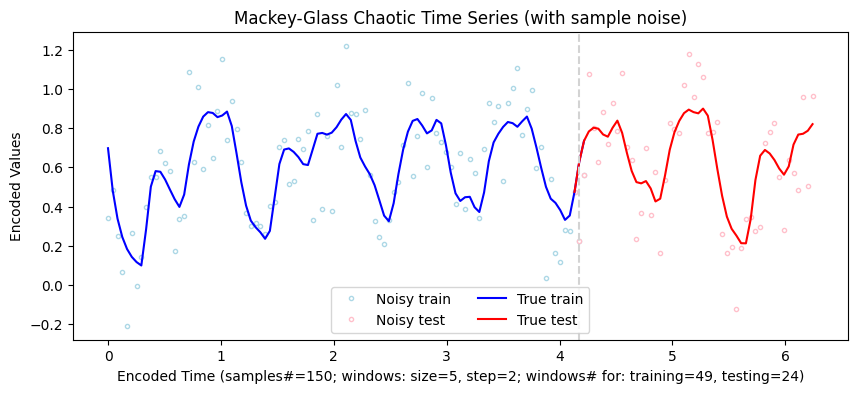

In [15]:
##### Plot flattened window partitions
#     The only way to plot windows is to first flatten them
#     In the process overlapping window elements will be averaged

### Flatten windows
X_train_flat_ts = ts_wind_flatten_avg(X_train_tens, wind_step)
X_test_flat_ts = ts_wind_flatten_avg(X_test_tens, wind_step)
X_train_noisy_flat_ts = ts_wind_flatten_avg(X_train_noisy_tens, wind_step)
X_test_noisy_flat_ts = ts_wind_flatten_avg(X_test_noisy_tens, wind_step)
X_train_flat_coords = ts_wind_flatten_avg(X_train_coords, wind_step)
X_test_flat_coords = ts_wind_flatten_avg(X_test_coords, wind_step)

# Plot partitions
plt.figure(figsize=(10, 4))
plt.plot(X_train_flat_coords, X_train_noisy_flat_ts, label="Noisy train", color="lightblue", linestyle='', mfc='white', marker='.')
plt.plot(X_test_flat_coords, X_test_noisy_flat_ts, label="Noisy test", color="pink", linestyle='', mfc='white', marker='.')
plt.plot(X_train_flat_coords, X_train_flat_ts, label="True train", color="blue")
plt.plot(X_test_flat_coords, X_test_flat_ts, label="True test", color="red")
plt.axvline(x=(X_train_flat_coords[-1]+X_test_flat_coords[0])/2, color="lightgray", linestyle='--')
plt.xlabel(f'Encoded Time (samples#={n_samples}; windows: size={wind_size}, step={wind_step}; windows# for: training={n_train}, testing={n_test})')
plt.ylabel('Encoded Values')
plt.title('Mackey-Glass Chaotic Time Series (with sample noise)')
plt.legend(loc='best', ncol=2)
plt.show()

## <font color="blue">Model development</font>

### QAE hyper-parameters

In [16]:
##### QAE hyper-parameters

### Model params
rot = 'Rxyz' # Ry / Rxyz
n_layers = 4
n_latent = 3
n_extra = 2
weight_scaler = 1.5
inv_decoder = True

### Derived params
n_trash = wind_size - n_latent
n_data = n_latent + n_trash
n_wires = n_latent + 2*n_trash + 2*n_extra

### Training params
n_epochs = 300     # 50 # 80 # 100 # 300
log_interv = 1     # History to be saved only once every interv or epochs
prompt_fract = 0.1 # Fraction of training / scoring loop log printout
acc_prec = 0.5     # Precision of accuracy calculation
shots = None       # None means using theoretical frequency distribution 
seed = 2025

### Other (CASE_NAME) invariant params
diff_method = 'backprop' # best, adjoint, 
interface = 'torch'      # None, 'torch','autograd'
level ='gradient'        # 'device', 'user'
shots = None             # We use a state vector simulator

### Utilities

In [17]:
### Counts the number of pytorch model parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Simulator device

In [18]:
##### Quantum simulator
sim = 'default.qubit' # default.qubit lightning.qubit lightning.gpu

# Enable GPU device if available
if torch.cuda.is_available():   # for Linux / Windows with GPU
    torch_device = 'cuda'
elif torch.mps.is_available():  # for Mac with GPU
    torch_device = 'mps'
else:
    torch_device = 'cpu'        # for everybody else
    
print(f'\nThe available devices:\t{sim} and {torch_device}')

# If you want to force CPU if working with GPU is slow (our unoptimised code)
torch_device = "cpu"

print(f'Devices to be used:\t{sim} and {torch_device}\n')


The available devices:	default.qubit and cpu
Devices to be used:	default.qubit and cpu



## Define, train and test a model
*Note that the trainnig model will be used further, however, the testting model is used only as a reference for its structural properties. The actual testing models will be generated dynamically.*

### PennyLane model creation

In [19]:
##### Creation of a model and its shape function

### Estimates the shape of the "full_qae"
#   n_latent: number of latent qubits
#   n_trash: number of trash qubits
#   n_layers: number of layers (repeats)
#   returns: shape
def full_qae_shape(n_latent, n_trash, n_extra=0, n_layers=1, rot='Ry'):
    n_wires = n_latent + n_trash + n_extra
    if rot == 'Ry':
        shape = qml.BasicEntanglerLayers.shape(n_layers=n_layers*2, n_wires=n_wires)
    elif  rot == 'Rxyz':
        shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers*2, n_wires=n_wires)
    return shape

### Full-QAE Circuit: Input + Encoder + Swap for trash reset + Decoder + Output
#   wires: list/array of wires to create a full QAE
#   n_latent: number of latent qubits
#   n_trash: number of trash qubits
#   n_extra: number of additional qubits to increase circuit breadth
#   n_layers: number of layers (repeats)
#   rot: rotation type, 'Ry' or 'Rxyz'
#   add_outseq: if True, the inverse of the input sequence will be added on output
#   invert_dec: If True the decoder ansatz will be inverted
#   returns: QAE building function which takes arguments
#     inputs: list/array of input values to be angle encoded
#     weights: list/array of weights shaped to be used in ansatz blocks

def full_qae(wires, n_latent, n_trash, n_extra, n_layers=1, rot='Ry', add_outseq=True, invert_dec=True):

    latent_wires = wires[0:n_latent]
    trash_wires = wires[n_latent:n_latent+n_trash]
    extra_wires = wires[n_latent+n_trash:n_latent+n_trash+n_extra]
    reinit_wires = trash_wires + extra_wires
    zero_wires = wires[n_latent+n_trash+n_extra:n_latent+2*n_trash+2*n_extra]
    data_wires = latent_wires + trash_wires
    anz_wires = latent_wires + trash_wires + extra_wires

    ### Encodes a sequence on in put (similar to AngleEncoding)
    def _sequence_encoder(wires, inputs):
        qml.AngleEmbedding(features=inputs, wires=wires, rotation='Y')
    
    ### Entangler shape
    def _entangler_shape(n_layers, n_wires, rot='Ry'):
        if rot == 'Ry':
            return qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_wires)
        elif rot == 'Rxyz':
            return qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
        else:
            return ()

    ### Entangler
    def _entangler(wires, weights, rot='Ry'):
        if rot == 'Ry':
            qml.BasicEntanglerLayers(weights, wires=anz_wires, rotation=qml.RY)
        elif rot == 'Rxyz':
            qml.StronglyEntanglingLayers(weights, wires=anz_wires)

    ### Full QAE encoder
    def _full_qae(weights, inputs):
        
        nonlocal wires, n_latent, n_trash, n_extra, n_layers, rot
        nonlocal latent_wires, trash_wires, extra_wires, data_wires, anz_wires
        nonlocal reinit_wires, zero_wires, add_outseq, invert_dec
                
        n_anz_wires = n_latent + n_trash + n_extra 
        n_data = n_latent + n_trash
    
        # Add input encoder
        _sequence_encoder(data_wires, inputs)
        qml.Barrier(wires)

        # In case the weights are passed in as a vector without any shape
        weights_shape = full_qae_shape(n_latent, n_trash, n_extra, n_layers, rot)
        weights = weights.reshape(weights_shape)
    
        # Find encoder/decoder shapes
        #    This function assumes symmetric QAE so they are identical
        enc_weights_shape = _entangler_shape(n_layers, n_anz_wires, rot=rot)
        dec_weights_shape = enc_weights_shape
     
        # Split and shape weights for encoder and decoder ansatze
        enc_weights = weights[:n_layers].reshape(enc_weights_shape)
        dec_weights = weights[n_layers:].reshape(dec_weights_shape)

        # Add encoder ansatz
        _entangler(anz_wires, enc_weights, rot=rot)        
      
        # Add initialisation of trash and extra space
        qml.Barrier(wires)
        for fw, tw in zip(reinit_wires, zero_wires):
            qml.SWAP(wires=[fw, tw])
        qml.Barrier(wires)
    
        # Add decoder ansatz
        if invert_dec:
            qml.adjoint(_entangler)(anz_wires, dec_weights, rot=rot)
        else:
            _entangler(anz_wires, enc_weights, rot=rot)
        qml.Barrier(wires)
    
        # Add output sequence if needed
        if add_outseq:
            qml.adjoint(_sequence_encoder)(data_wires, inputs)
            
        return [qml.expval(qml.PauliZ(wires=w)) for w in data_wires]

    return _full_qae

In [20]:
if debug_level > 0:
    test_n_latent = 3; test_n_trash = 2; test_n_extra = 1; test_n_layers=2
    test_n_inputs = test_n_latent + test_n_trash
    test_n_wires = test_n_latent + 2*test_n_trash + 2*test_n_extra
    test_wires = list(range(test_n_wires))
    test_rot = 'Ry'
    
    test_shape = full_qae_shape(test_n_latent, test_n_trash, test_n_extra, n_layers=test_n_layers, rot=test_rot)
    test_n_weights = np.prod(test_shape)
    print(f'Full-QAE shape: {test_shape}, weights: {int(test_n_weights)}\n')
    
    test_data = torch.linspace(100, 200, test_n_inputs, requires_grad=False)
    test_weights = torch.rand(test_shape, requires_grad=True)
    
    print(f'Data ({test_data.shape}): \n{test_data}\n')
    print(f'Weights ({test_weights.shape}): \n{test_weights}\n')

In [21]:
if debug_level > 0:
    ### Testing full-QAE for training
    
    # Define a static full-QAE
    test_qae = full_qae(test_wires, test_n_latent, test_n_trash, test_n_extra, n_layers=test_n_layers, rot=test_rot, add_outseq=False, invert_dec=True)
    
    # Create and draw a full-QAE, add wires for SWAP space (only latent area goes through)
    test_dev = qml.device(sim, wires=range(test_n_wires+test_n_trash+test_n_extra), shots=shots)
    test_qae_qc = qml.QNode(test_qae, test_dev, interface=interface, diff_method=diff_method)
    draw_circuit(test_qae_qc, scale=0.4, title='Full-QAE with SWAP Trash Reset', level='device') \
        (test_weights, test_data) # expansion_strategy='device'/'gradient'

    # Apply the model to sample data
    results = test_qae_qc(test_weights, test_data) #[test_data, test_data])
    print(f'test_qae_qc(test_weights, test_data):\n{torch.stack(results)}\n')

### PyTorch with PennyLane model creation

In [22]:
### Create a PyTorch model with a PennyLane circuit within

class Hybrid_QAE(nn.Module):

    def __init__(self, sim, n_latent, n_trash, n_extra, n_layers=1, rot='Ry', weight_scaler=0.1,
                 invert=True, shots=None, interface='torch', diff_method='backprop'):
        
        super(Hybrid_QAE, self).__init__()

        self.sim = sim
        self.n_wires = n_latent + 2*n_trash + 2*n_extra
        self.n_latent = n_latent
        self.n_trash = n_trash
        self.n_extra = n_extra
        self.n_layers = n_layers
        self.shape = (n_layers, n_latent+n_trash, 3)
        self.rot = rot
        self.invert = invert
        self.shots = shots
        self.wires = list(range(n_wires))
        self.dev = qml.device(self.sim, wires=self.wires, shots=self.shots)
        self.interface = interface
        self.diff_method = diff_method
        self.weight_scaler = weight_scaler

        # Wrap a torch layer around the PennyLane model
        quant_layer = self.qlayer()
        layers = [quant_layer]
        self.model_pt = nn.Sequential(*layers)  

    ### Define a quantum layer
    def qlayer(self):
        
        # Define the quantum model and its circuit (or node, save it for later)
        self.shape = full_qae_shape(self.n_latent, self.n_trash, self.n_extra, 
            n_layers=self.n_layers, rot=self.rot)
        model_pl = full_qae(self.wires, self.n_latent, self.n_trash, self.n_extra, 
            n_layers=self.n_layers, rot=self.rot, invert_dec=self.invert) #, add_outseq=True)
        self.model_qc = qml.QNode(model_pl, 
            self.dev, interface=self.interface, diff_method=self.diff_method)

        # Define the shape of the model weight parameters
        # Note that the name "weights" must match the param name defined in function
        weights_shapes = {"weights": self.shape}
        init_method = {"weights": 
            lambda p: torch.nn.init.uniform_(p, a=0.0, b=np.pi*self.weight_scaler)}

        # Turn the circuit into a Torch-compatible quantum layer
        quant_layer = qml.qnn.TorchLayer(self.model_qc, 
            weight_shapes=weights_shapes, init_method=init_method)
        return quant_layer

    ### Return the quantum model circuit
    def qmodel_qc(self):
        return self.model_qc
 
    ### Apply the model to data (forward step)
    def forward(self, x):
        y = self.model_pt(x)
        return y

### Test the PennyLane/PyTorch hybrid model before use

In [23]:
if debug_level > 0:

    ### Parameters of a test circuit
    t_layers = 2; t_latent = 2; t_trash = wind_size - t_latent; t_extra = 2; t_rot = 'Ry' 
    t_inv = False; t_ws = weight_scaler
    
    ### Create a test model and draw the test model circuit
    test = Hybrid_QAE(sim, t_latent, t_trash, t_extra, n_layers=t_layers, rot=t_rot, 
        shots=shots, invert=t_inv, weight_scaler=t_ws,
        interface=interface, diff_method=diff_method).double().to(torch_device)
    shape = test.shape
    n_weights = np.prod(shape)
    
    print(f'\nAll weights: {count_params(test)}, Q weights: {n_weights}, Epochs: {n_epochs}')
    print(f'\nTest results: {test(X_train_tens[0:5])}\n')
    
    ### Show the structure of the torch model
    print(test.eval())

    ### Draw the test model circuit
    weights = torch.rand(test.shape, requires_grad=True)
    draw_circuit(test.qmodel_qc(), scale=0.5, level='device',
        title=f'Test circuit:') \
        (weights, X_train_tens[0])

## Creation and training of the PennyLane/PyTorch model

### Train the model

In [24]:
##### Training loop

def train_with_noise(model, X, y, cost_fun, optimizer, n_epochs,
                     log_interv=100, prompt_fract=0.1, start_time=0, level=2, seed=0,
                     wind_size=8, wind_step=4, noise=0, scale_low=0, scale_high=2*np.pi):

    def closure():
        nonlocal X_noisy_tens, y_pure_tens, model, optimizer, cost_fun
        if torch.is_grad_enabled():
            optimizer.zero_grad()
        output = model(X_noisy_tens)
        cost = cost_fun(output, y_pure_tens)
        if cost.requires_grad:
            cost.backward()
        return cost

    ### For reproducibility
    #   Set a default random seed
    if seed == 0: seed = int(time.time()*1000) % 10000
    np.random.seed(seed)
    
    ### Prepare training
    hist_cost = []
    hist_params = []
    hist_noise = []
    
    ### Prepare tensors of pure training windows to be used as y output
    #   We ignore the test partition in training
    _, y_pure_tens, _, _ = create_sw_tens(X, y, noise=0, 
        wind_size=wind_size, wind_step=wind_step, range_low=scale_low, range_high=scale_high)
    
    ### Set the clock
    if start_time == 0: start_time = time.time() 
        
    ### Training loop
    for iter in range(n_epochs):
    
        # Add noise to pure windows to be used as X input
        #   We ignore the test partition in training
        _, X_noisy_tens, _, _ = create_sw_tens(X, y, noise=noise, seed=seed+iter,
            wind_size=wind_size, wind_step=wind_step, range_low=scale_low, range_high=scale_high)
        hist_noise.append(X_noisy_tens)

        # Reset optimiser gradients
        optimizer.zero_grad()

        # Perform a forward step, note that returned output is transposed 
        # params = optimizer.param_groups[0]['params'][0].clone()
        y_recov_tens = model(X_noisy_tens)
        assert y_recov_tens.shape == y_pure_tens.shape, \
            f"*** Shape mismatch: {y_recov_tens.shape} vs {y_pure_tens.shape}"
        cost = cost_fun(y_recov_tens, y_pure_tens)
        curr_cost = cost.item()

        elapsed_time = time.time()-start_time
        if iter % log_interv == 0:
            hist_cost.append(curr_cost)
            hist_params.append(copy.deepcopy(model.state_dict()))
        if (prompt_fract == 0) or (iter % int(prompt_fract*n_epochs) == 0):
            print(f'{iter:5d} ({int(elapsed_time):04d} sec) cost={curr_cost:06.5f}')
    
        # Perform a backward step
        cost.backward()
        optimizer.step()

    ### Print the training summary
    min_cost = np.min(hist_cost)
    min_iter = np.argmin(hist_cost)
    opt_params = hist_params[min_iter]
    
    ### Print the training summary
    print(f'\nTraining completed: epochs={n_epochs}, min cost={min_cost:06.5f} @ {min_iter}, time={int(elapsed_time):03d} secs\n')

    return hist_cost, hist_params, hist_noise, (min_iter, min_cost, elapsed_time)

In [25]:
##### Prepare and train the model

### For reproducibility
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Create a model
qae_model = Hybrid_QAE(sim, n_latent, n_trash, n_extra, n_layers=n_layers, rot=rot, 
    invert=inv_decoder, shots=shots, weight_scaler=weight_scaler,
    interface=interface, diff_method=diff_method).double().to(torch_device)

### Select a PyTorch optimiser
opt = torch.optim.NAdam(qae_model.parameters(), lr=0.01)

### Select loss function
mse_loss = torch.nn.MSELoss()

### Train the model
print(f'\nTraining the model:')
hist_cost, hist_params, hist_noise, stats = \
    train_with_noise(qae_model, X, y, mse_loss, opt, n_epochs,
        wind_size=wind_size, wind_step=wind_step, noise=noise, scale_low=y_low, scale_high=y_high,
        log_interv=log_interv, prompt_fract=prompt_fract, start_time=0, level=2, seed=seed)


Training the model:
    0 (0000 sec) cost=0.38531
   30 (0001 sec) cost=0.15910
   60 (0003 sec) cost=0.03159
   90 (0005 sec) cost=0.01220
  120 (0007 sec) cost=0.01148
  150 (0009 sec) cost=0.01081
  180 (0011 sec) cost=0.01021
  210 (0012 sec) cost=0.01104
  240 (0014 sec) cost=0.00916
  270 (0016 sec) cost=0.01180

Training completed: epochs=300, min cost=0.00630 @ 242, time=018 secs



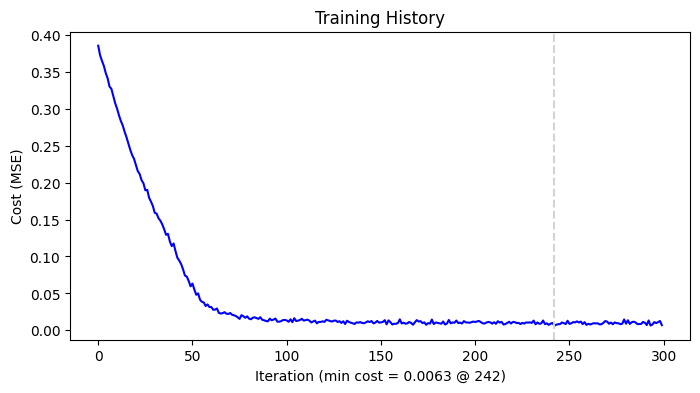

In [26]:
### Plot training cost

# Find the minimum cost
min_cost = np.min(hist_cost)
min_idx = np.argmin(hist_cost)

# Plot the chart
plt.figure(figsize=(8, 4))
plt.plot(hist_cost, label="Cost", color="blue")
plt.axvline(x=min_idx, color="lightgray", linestyle='dashed')
plt.xlabel(f'Iteration (min cost = {min_cost:0.4f} @ {min_idx})')
plt.ylabel('Cost (MSE)')
plt.title('Training History')
plt.show()

### Flattening data and best model results

In [27]:
##### Apply optimum model to data partitions and flatten them

### Identify optimum training parameters 
opt_params = hist_params[stats[0]]
qae_model.load_state_dict(opt_params)

### Reconstruct pure and noisy training TSs
pred_from_pure_train_tens = qae_model(X_train_tens).detach().numpy()
pred_from_pure_test_tens = qae_model(X_test_tens).detach().numpy()
pred_from_noisy_train_tens = qae_model(X_train_noisy_tens).detach().numpy()
pred_from_noisy_test_tens = qae_model(X_test_noisy_tens).detach().numpy()

### Flatten recovered TSs
pred_from_pure_train_flat = ts_wind_flatten_avg(pred_from_pure_train_tens, wind_step)
pred_from_pure_test_flat = ts_wind_flatten_avg(pred_from_pure_test_tens, wind_step)
pred_from_noisy_train_flat = ts_wind_flatten_avg(pred_from_noisy_train_tens, wind_step)
pred_from_noisy_test_flat = ts_wind_flatten_avg(pred_from_noisy_test_tens, wind_step)

### Flatten all collected Gaussian noise used in training
#   It is used only as an illustration for plotting
flat_noisy_ts = []
for noisy_ts in hist_noise:
    noisy_y_points = ts_wind_flatten_avg(noisy_ts, wind_step)
    flat_noisy_ts.append(noisy_y_points)
flat_noisy_ts = np.stack(flat_noisy_ts).numpy()

## Model scoring

In [28]:
### Calculate a model score as defined by the scoring function and data
def score_model(model, params, X, y, score_fun, score_name='Score', 
                score_min=True, prompt_fract=0):

    ### Initialise scoring
    score_hist = []
    if score_min:
        opt_score = float(np.inf)
    else:
        opt_score = -float(np.inf)

    ### Flatten y
    y_flat = ts_wind_flatten_avg(y.detach().numpy(), wind_step)

    ### Calculate scores
    print(f'\nCalculating scores for {score_name}:')
    epochs = len(hist_params)
    with torch.no_grad():
        for iter in range(epochs):
            qae_model.load_state_dict(hist_params[iter])
            pred = qae_model(X).detach().numpy()
            pred_flat = ts_wind_flatten_avg(pred, wind_step)
            curr_score = score_fun(pred_flat, y_flat)
            if type(curr_score) is torch.Tensor:
                curr_score = curr_score.item()
            score_hist.append(curr_score)
            if (not score_min and (curr_score > opt_score)) or \
               (score_min and (curr_score < opt_score)):
                opt_score = curr_score
                opt_score_iter = iter
            if (prompt_fract == 0) or (iter % int(prompt_fract*epochs) == 0):
                print(f'{iter:5d} / {epochs:3d}, '+
                      f'{score_name} = {curr_score:.6f}')
    return score_hist, opt_score, opt_score_iter

In [29]:
### Calculate scores for different samples and scoring functions
start_score_time = time.time()

train_mse_hist, train_min_mse, train_min_mse_iter = \
    score_model(qae_model, hist_params, X_train_noisy_tens, y_train_tens, mean_squared_error, 
    score_name='Train MSE', score_min=True, prompt_fract=prompt_fract)
test_mse_hist, test_min_mse, test_min_mse_iter = \
    score_model(qae_model, hist_params, X_test_noisy_tens, y_test_tens, mean_squared_error, 
    score_name='Test MSE', score_min=True, prompt_fract=prompt_fract)
train_r2_hist, train_min_r2, train_min_r2_iter = \
    score_model(qae_model, hist_params, X_train_noisy_tens, y_train_tens, r2_score, 
    score_name='Train R2', score_min=False, prompt_fract=prompt_fract)
test_r2_hist, test_min_r2, test_min_r2_iter = \
    score_model(qae_model, hist_params, X_test_noisy_tens, y_test_tens, r2_score, 
    score_name='Test R2', score_min=False, prompt_fract=prompt_fract)

elapsed_score_time = time.time() - start_score_time
score_time_str = time.strftime("%H:%M:%S", time.gmtime(elapsed_score_time))

mse_train_report = f'Train: min MSE = {round(train_min_mse, 5):05.4f} @ {train_min_mse_iter:04d}'
mse_test_report =  f'Test:  min MSE = {round(test_min_mse, 5):05.4f} @ {test_min_mse_iter:04d}'
r2_train_report = f'Train: max R2  = {round(train_min_r2, 5):05.4f} @ {train_min_r2_iter:04d}'
r2_test_report =  f'Test:  max R2  = {round(test_min_r2, 5):05.4f} @ {test_min_r2_iter:04d}'

print(f'\nScoring completed: epochs={len(hist_params)} '+\
      f'in {elapsed_score_time:0.0f} sec ({score_time_str})\n\n'+\
      f'\t{mse_train_report}\t{mse_test_report}\n'+\
      f'\t{r2_train_report}\t{r2_test_report}\n')


Calculating scores for Train MSE:
    0 / 300, Train MSE = 0.379075
   30 / 300, Train MSE = 0.168041
   60 / 300, Train MSE = 0.030626
   90 / 300, Train MSE = 0.014413
  120 / 300, Train MSE = 0.012223
  150 / 300, Train MSE = 0.011685
  180 / 300, Train MSE = 0.011350
  210 / 300, Train MSE = 0.011443
  240 / 300, Train MSE = 0.011350
  270 / 300, Train MSE = 0.011204

Calculating scores for Test MSE:
    0 / 300, Test MSE = 0.431310
   30 / 300, Test MSE = 0.198478
   60 / 300, Test MSE = 0.034177
   90 / 300, Test MSE = 0.009778
  120 / 300, Test MSE = 0.006928
  150 / 300, Test MSE = 0.006948
  180 / 300, Test MSE = 0.006001
  210 / 300, Test MSE = 0.006646
  240 / 300, Test MSE = 0.006423
  270 / 300, Test MSE = 0.005681

Calculating scores for Train R2:
    0 / 300, Train R2 = -787.034724
   30 / 300, Train R2 = -127.754508
   60 / 300, Train R2 = -3.534076
   90 / 300, Train R2 = 0.280745
  120 / 300, Train R2 = 0.559969
  150 / 300, Train R2 = 0.647143
  180 / 300, Train R2 

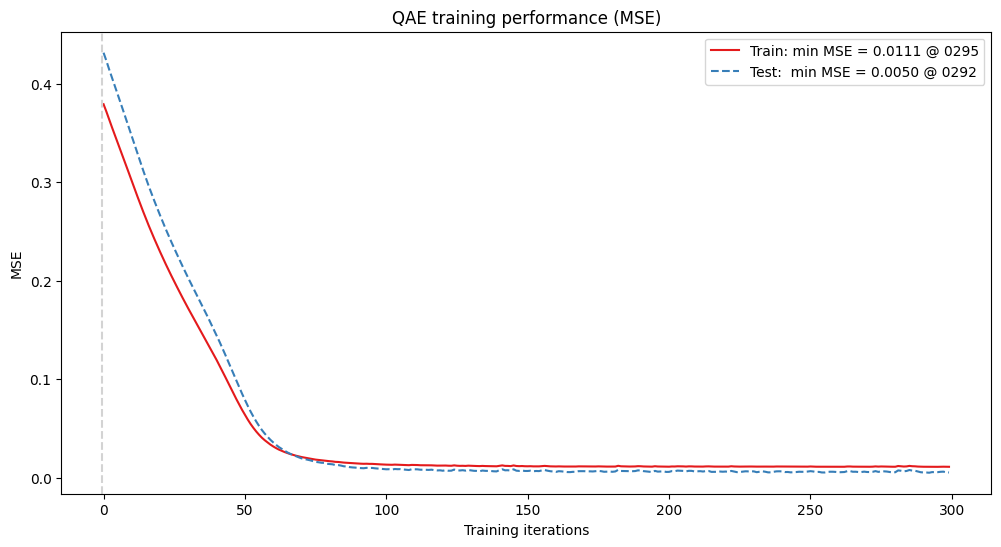

In [30]:
multi_plot_series(
    [train_mse_hist, test_mse_hist], X_list=[0, 0], 
    labels=[mse_train_report, mse_test_report], 
    lines=['solid', 'dashed'],
    rcParams=(12, 6), xlabel='Training iterations', ylabel='MSE', #ylim=(0, 1),
    legend_cols=1, smooth_weight=0.4, title='QAE training performance (MSE)')

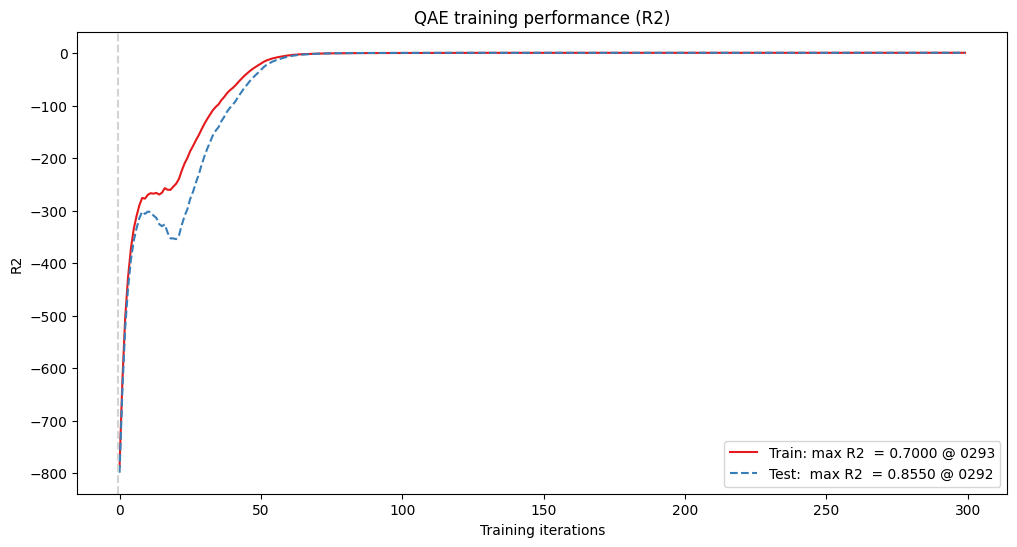

In [31]:
multi_plot_series(
    [train_r2_hist, test_r2_hist], X_list=[0, 0], 
    labels=[r2_train_report, r2_test_report], 
    lines=['solid', 'dashed'],
    rcParams=(12, 6), xlabel='Training iterations', ylabel='R2', #ylim=(0, 1),
    legend_cols=1, smooth_weight=0.4, title='QAE training performance (R2)')

## Best model fit for sample data

In [32]:
##### Calculate score statistics to show in charts
#     Note that all pure X = pure y, noise was injected into X only

print()
print(f'Comparison clean vs noisy signal & clean vs signal recovered from noise')
print()

mse_train_pure_vs_noisy = mean_squared_error(X_train_flat_ts, X_train_noisy_flat_ts)
mse_train_pure_vs_rec_from_noisy = mean_squared_error(X_train_flat_ts, pred_from_noisy_train_flat)
mse_test_pure_vs_noisy = mean_squared_error(X_test_flat_ts, X_test_noisy_flat_ts)
mse_test_pure_vs_rec_from_noisy = mean_squared_error(X_test_flat_ts, pred_from_noisy_test_flat)

print(f'MSE train: {mse_train_pure_vs_noisy:0.4f} (clean vs noise) ==> {mse_train_pure_vs_rec_from_noisy:0.4f} (clean vs recovered)')
print(f'MSE test:  {mse_test_pure_vs_noisy:0.4f} (clean vs noise) ==> {mse_test_pure_vs_rec_from_noisy:0.4f} (clean vs recovered)')
print()

r2_train_pure_vs_noisy = r2_score(X_train_flat_ts, X_train_noisy_flat_ts)
r2_train_pure_vs_rec_from_noisy = r2_score(X_train_flat_ts, pred_from_noisy_train_flat)
r2_test_pure_vs_noisy = r2_score(X_test_flat_ts, X_test_noisy_flat_ts)
r2_test_pure_vs_rec_from_noisy = r2_score(X_test_flat_ts, pred_from_noisy_test_flat)

print(f'R2 train:  {r2_train_pure_vs_noisy:0.4f} (clean vs noise) ==> {r2_train_pure_vs_rec_from_noisy:0.4f} (clean vs recovered)')
print(f'R2 test:   {r2_test_pure_vs_noisy:0.4f} (clean vs noise) ==> {r2_test_pure_vs_rec_from_noisy:0.4f} (clean vs recovered)')
print()


Comparison clean vs noisy signal & clean vs signal recovered from noise

MSE train: 0.0335 (clean vs noise) ==> 0.0113 (clean vs recovered)
MSE test:  0.0349 (clean vs noise) ==> 0.0060 (clean vs recovered)

R2 train:  0.2167 (clean vs noise) ==> 0.7363 (clean vs recovered)
R2 test:   -0.0038 (clean vs noise) ==> 0.8283 (clean vs recovered)



### Compare pure data vs noisy and recovered data

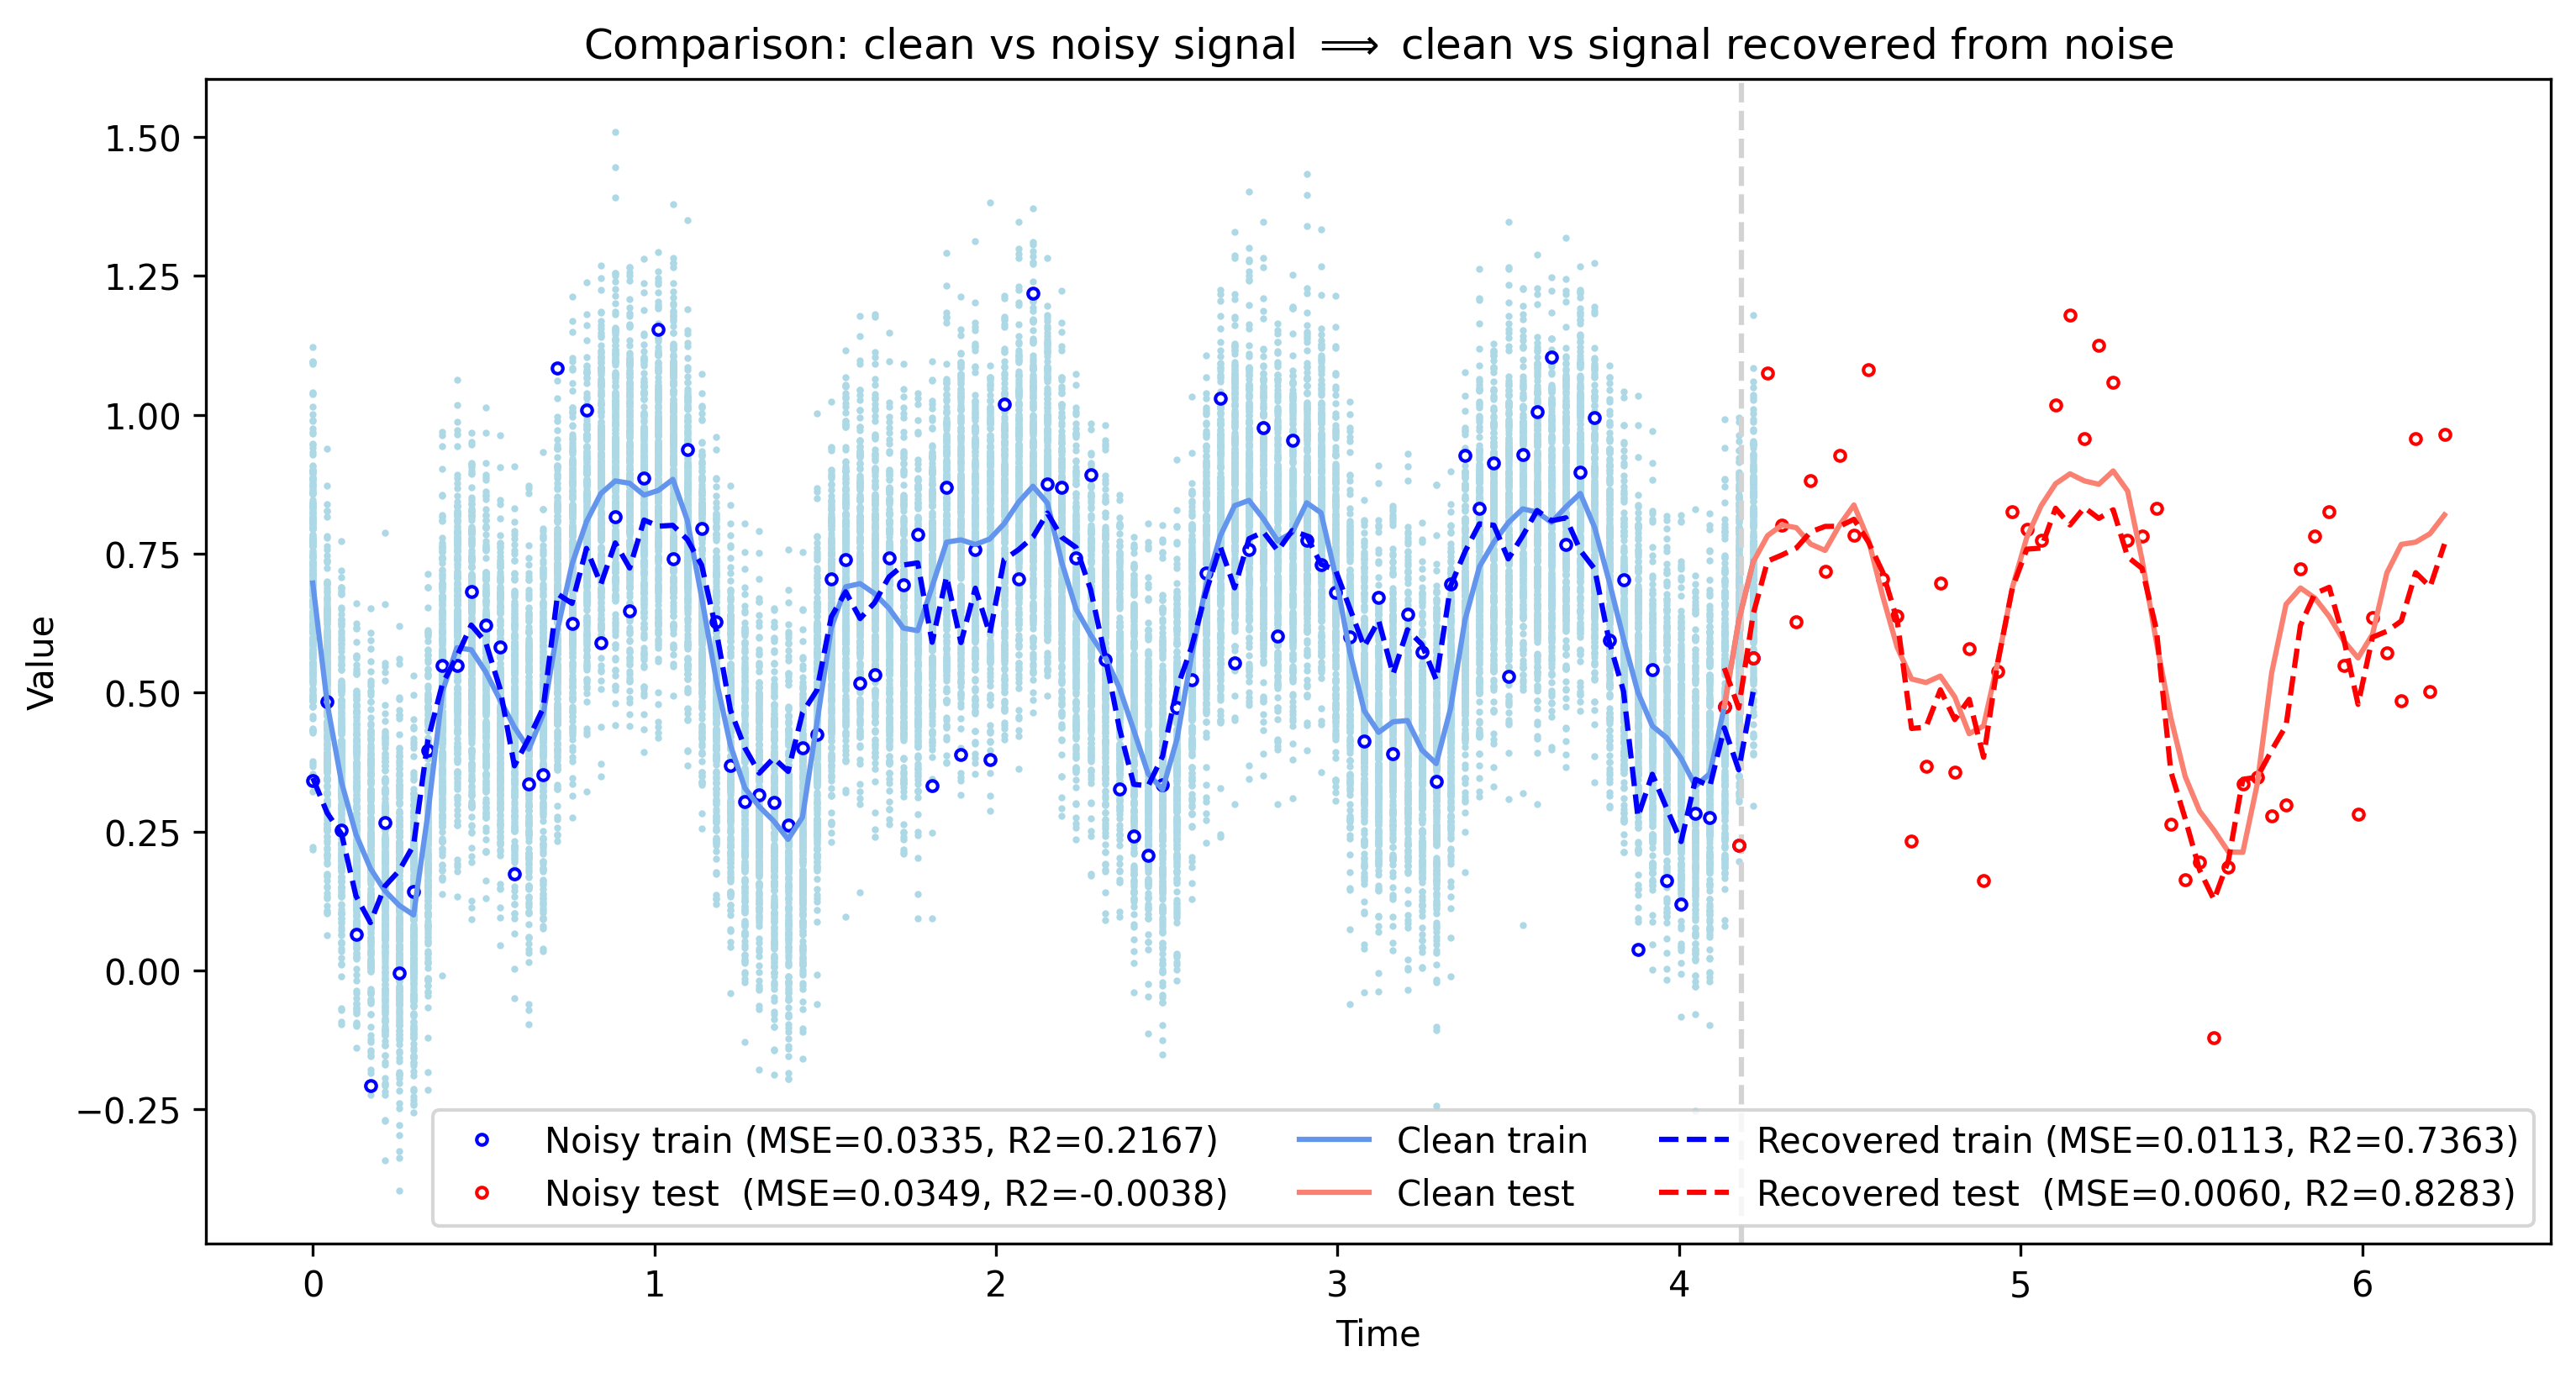

In [33]:
##### Plot the original and recovered data with added performance metrics

### Prepare X, y series for plotting
X_list = [X_train_flat_coords, X_test_flat_coords, 
          X_train_flat_coords, X_test_flat_coords, 
          X_train_flat_coords, X_test_flat_coords]
y_list = [X_train_noisy_flat_ts, X_test_noisy_flat_ts,
          X_train_flat_ts, X_test_flat_ts, 
          pred_from_noisy_train_flat, pred_from_noisy_test_flat]
X_bg = [X_train_flat_coords]; y_bg = flat_noisy_ts

### Chart properties
title = f"Comparison: clean vs noisy signal $\Longrightarrow$ clean vs signal recovered from noise"
labels = [f"Noisy train (MSE={mse_train_pure_vs_noisy:0.4f}, R2={r2_train_pure_vs_noisy:0.4f})", 
          f"Noisy test  (MSE={mse_test_pure_vs_noisy:0.4f}, R2={r2_test_pure_vs_noisy:0.4f})",
          "Clean train", "Clean test",
          f"Recovered train (MSE={mse_train_pure_vs_rec_from_noisy:0.4f}, R2={r2_train_pure_vs_rec_from_noisy:0.4f})", 
          f"Recovered test  (MSE={mse_test_pure_vs_rec_from_noisy:0.4f}, R2={r2_test_pure_vs_rec_from_noisy:0.4f})"]
line_cols = ["blue", "red", "cornflowerblue", "salmon", "blue", "red"]
line_styles = ["", "", "solid", "solid", "dashed", "dashed"]
marker_cols = ["white", "white", "", "", "", ""]
marker_styles = [".", ".", "", "", "", ""]
bgls=['']; bglc=['lightblue']; bgms=['.']; bgmc=['lightblue'] # these will repeat

### Plot all data including all noisy signals used in training (small light blue dots),
#   as well as noise signals given as input for noise elimination (blue and red dots).
#   The "true" signals are solid, and signals recovered from noise are dashed.
multi_plot_flat_ts(
    X_list, y_list, X_bg=X_bg, y_bg=y_bg,
    bg_line_style=bgls, bg_line_cols=bglc, bg_marker_style=bgms, bg_marker_cols=bgmc,
    vert_lines=['', '--'], vert_line_col='lightgray',
    labels=labels, line_cols=line_cols, line_styles=line_styles, 
    marker_styles=marker_styles, marker_cols=marker_cols,
    xlim=None, ylim=None, dpi=300, xlabel='Time', ylabel='Value',
    legend_cols=3, title=title, sigma=0.05, save_plot=None)

## Write your observations here

- Observation 1:
- Observation 2:
- Observation 3:
- Observation 4:
- Observation 5:
- Observation 6:
- Observation 7:


## Modifications (do not remove)
Under the [GPL-3.0](https://www.gnu.org/licenses/gpl-3.0.txt) license, if you perform any changes to this notebook, please list them here, adding a note with your name, contact details, date and changes to the code.

- [Jacob Cybulski](http://jacobcybulski.com) (2025, 1 April): The author of this notebook added this section to record all code changes
- [Jacob Cybulski](http://jacobcybulski.com) (2026, 2 October): Now also compatible with...<br>
  pennylane                 0.45.0<br>
  pennylane_lightning       0.45.0<br>
  torch                     2.11.0+cpu<br>
  torchaudio                2.11.0<br>
  torchvision               0.26.0+cpu<br>

# Software in use (Linux)

In [34]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.45.0
pennylane_catalyst        0.15.0
pennylane_lightning       0.45.0
pennylane_lightning_gpu   0.45.0
torch                     2.11.0+cpu
torchaudio                2.11.0
torcheval                 0.0.7
torchmetrics              1.9.0
torchsummary              1.5.1
torchvision               0.26.0+cpu
